In [1]:
import sys, os
from pathlib import Path

project_root = Path("Controlled_EDMD.ipynb").resolve().parent.parent
package_root = project_root /"KRTB_pyKoopman_EDMD"
sys.path.insert(0, str(package_root))

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from ASR import custom_obs
import pykoopman as pk
from pykoopman import observables, regression
from KRTB_pyKoopman import KoopmanModelTrainer, KoopmanAnalysis, integralRK4
from controller import KoopmanMPC
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

## Configuratoin

In [3]:
curdir = os.path.dirname("Controlled_EDMD.ipynb")
config_path = os.path.join(curdir, "config", "benchmark_ASR_forward.json")
stream = print

## Access simulated trajectory and EDMDc model

In [4]:
kmt = KoopmanModelTrainer(config_path, curdir, save_model=True, save_sim_data=True, stream=stream)
use_saved_data = True
if use_saved_data:
    states, controls, t_vec = kmt.loadSimTrajectories(control=True)
    pk_model = kmt.loadPyKoopmanModel()
else:
    states, controls, t_vec = kmt.simTrajWithControl(seed=4)
    
    reg = regression.EDMDc()
    obs = custom_obs
    pk_model = kmt.trainPyKoopmanModel(states, controls=controls, regressor=reg, observables=obs)

Simulated trajectories loaded from: sim_trajectories/benchmark_ASR_forward.npz
 Num. simulated trajectories: 10000
Simulation time span (sec): 4.950 [0.000, 4.950]
Trained model loaded from: models/benchmark_ASR_forward.pkl


## How well our EDMDc model can predict a trainig trajectory?

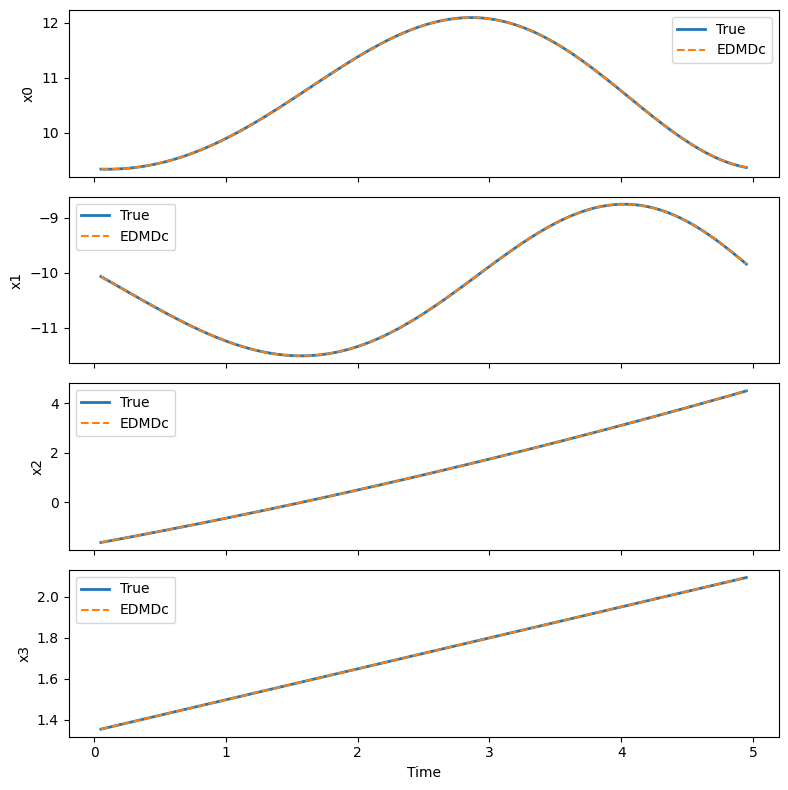

In [5]:
test_traj = states[0]
test_U = controls[0]
X = test_traj[:-1]
X_next_true = test_traj[1:]
U = test_U[:-1]

X_next_pred = pk_model.predict(X, U)
t = t_vec[1:]

n_states = X.shape[1]

fig, axs = plt.subplots(n_states, 1, figsize=(8, 2*n_states), sharex=True)

for i in range(n_states):
    axs[i].plot(t, X_next_true[:, i], label="True", linewidth=2)
    axs[i].plot(t, X_next_pred[:, i], "--", label="EDMDc")
    axs[i].set_ylabel(f"x{i}")
    axs[i].legend()

axs[-1].set_xlabel("Time")
plt.tight_layout()
plt.show()

## How well our EDMDc model can simulate a trajectory?

/home/ali/my_ws/Thesis/venv/lib/python3.10/site-packages/pykoopman/koopman.py:302: ComplexWarning: Casting complex values to real discards the imaginary part
  x = x.astype(self.A.dtype)


(50, 4)


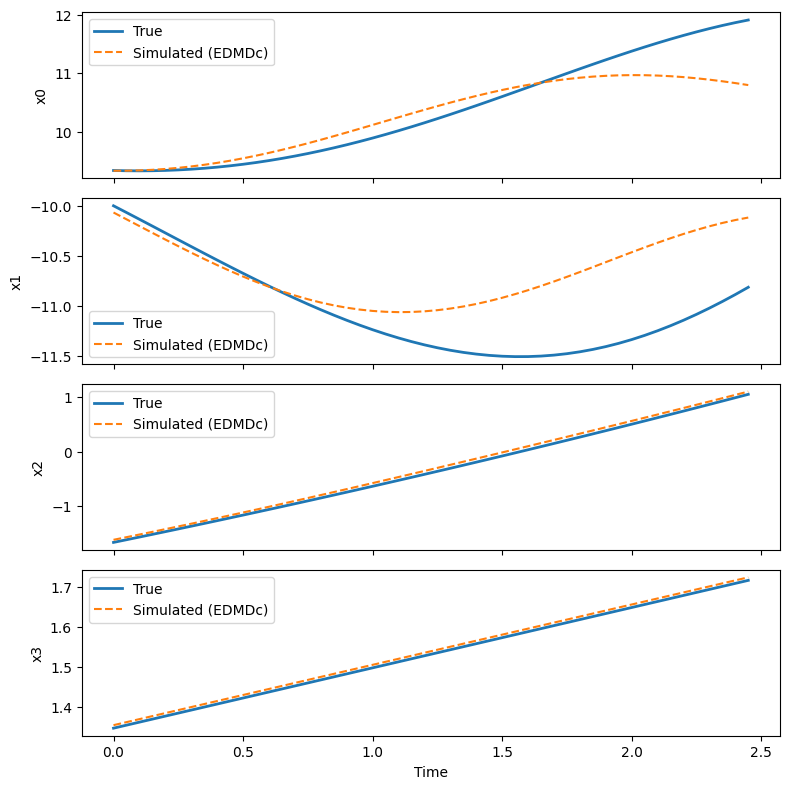

In [6]:
x0 = test_traj[0]
n_ss = 50
U_sim = test_U[:n_ss]

X_sim = pk_model.simulate(x0, U_sim, n_ss)
print(X_sim.shape)

t = t_vec[:X_sim.shape[0]]
X_true = test_traj[:n_ss]

n_states = X_true.shape[1]

fig, axs = plt.subplots(n_states, 1, figsize=(8, 2*n_states), sharex=True)

for i in range(n_states):
    axs[i].plot(t, X_true[:, i], label="True", linewidth=2)
    axs[i].plot(t, X_sim[:, i], "--", label="Simulated (EDMDc)")
    axs[i].set_ylabel(f"x{i}")
    axs[i].legend()

axs[-1].set_xlabel("Time")
plt.tight_layout()
plt.show()

## Koopman based Model Pridictive Control

In [7]:
def build_reference(traj, i, Np):
    T = traj.shape[0]
    # Select reference window. Clamp if i+Np exceeds T-1
    end = min(i + Np, T)
    window = traj[i:end]

    # If the window is shorter, repeat the last state
    if window.shape[0] < Np:
        last = window[-1]
        repeat_count = Np - window.shape[0]
        repeat_block = np.tile(last, (repeat_count, 1))
        window = np.vstack((window, repeat_block))

    # Return shape (nx, Np)
    return window.T

In [10]:
Q = np.diag([1.0, 1.0, 10, 1])
R = np.diag([0.005, 0.11])
kmpc = KoopmanMPC(pk_model, R, Q, u_min=np.array([-0.5, -np.pi/6]), 
                  u_max=np.array([0.5, np.pi/6]), n_horizon=12)

### test KMPC

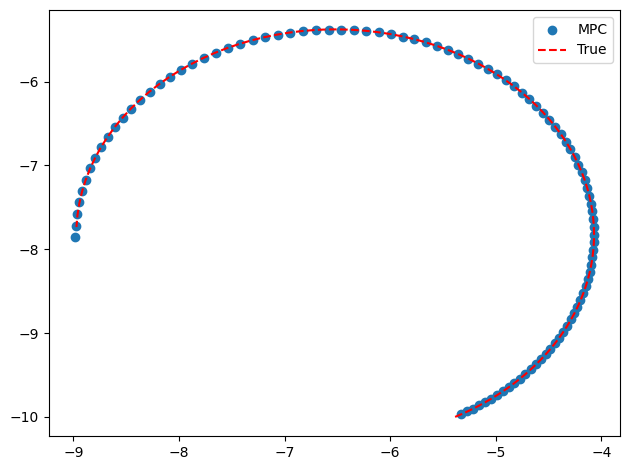

In [14]:
traj = states[200]

n_steps = traj.shape[0]
dt = 0.05
pos = np.zeros((n_steps, 2))

x = traj[0, :]
for i in range(n_steps):
    x_ref = build_reference(traj, i, kmpc.Np)
    u = kmpc.run(x, x_ref)
    x = integralRK4(kmt.system.ff, x.reshape(1, -1), u, dt).flatten()
    pos[i, :] = x[:2]

plt.scatter(pos[:, 0], pos[:, 1], label="MPC")
plt.plot(traj[:, 0], traj[:, 1], '--r', label="True")
plt.legend()
plt.tight_layout()
plt.show()